                                                            CNN , VISIONS                                               

CNN - convolutional neural network

in previos phase nnnmodules we were changing images into long list type number to recognize but in real life ... images are diff use colors etc

                                            TOPIC - Convolutions or convo2d                                                             

1st layer -  lines , edges
2nd layer - curves, corners ( combine )
3rd layer - converts shapes into numbers or target


In [ ]:
#syntax

"""
nn.conv2d(in_channels, out_channels, kernel_size, stride, padding)

inchannels - IN ( kitni layers aayi )

black & white - 1
rgb - 3
[batch, channels, height, width]
[1,1,28,28]


out_channels 

each output channel = 1 pattern detecter
8
[1,1,28,28]
[1,8,?,?]


kernal_size

3 = 3 x 3 pixels
5 = 5 x 5 pixels
if kernal size is bigger than it will see more context
if kernal size is small than it will just find small things ( context )

stride - 2 ( we are saying skip every 2nd pixel )
moves ? 


padding - ( padding = 1 ) <- example

have to see edges or not ?

edge problems - 
    1. filter cannot fully sit on edges
    2. image shrinks
    
why it is imp -
    increase the stability of image size 
    it is very common 
    
    
    
example - 
    conv = nn.Conv2d(
        in_channels = 1,
        out_channels = 1,
        kernal_size = 3,
        stride = 1,
        padding = 0 (edges will be lost )
    )
    
Pooling - 

nn.MaxPool2d

"""

In [ ]:
import torch
import torch.nn as nn 

image = torch.randn(1,1,28,28)

conv = nn.Conv2d( #change the values to see changes
    in_channels = 1,    #how many layers of input comes in
    out_channels = 8,   #pattern detecter ( eyes )
    kernel_size = 3,    #pixel box size to check at once
    stride = 1, #how many steps to skip 
    padding = 0 #see padding is 0 so last 2 pixels got ignored
)

output = conv(image)

print("Input Image :",image.shape)
print("Output Image : ",output.shape) #output isnt image it just says it got 8 diff patterns ( high value means strong pattern and low value means low lvl pattern)

Input Image : torch.Size([1, 1, 28, 28])
Output Image :  torch.Size([1, 1, 26, 26])


Why cnn keeps making images small! ( pooling is the ans )

Pooling - Keeps strong data and discards the weaker ones ( removal of weak point ) ( keeps dominant values)

In [39]:
import torch
import torch.nn

x = torch.randn(1,8,28,28)

pool = nn.MaxPool2d(kernel_size=2)

y = pool(x)

print("Before pooling :",x.shape)
print("After pooling :",y.shape) #reduces the value if needed. choti moti details ko nikaal dega main value rkhega like jo kaam ki values ho.


Before pooling : torch.Size([1, 8, 28, 28])
After pooling : torch.Size([1, 8, 14, 14])


                                            CNN ARCHITECTURE FLOW                                           

image - (input image) ( raw pixels )
    |
conv2d ( finds simple values ) ( edges ko dhundega )
    |
relu    (keep useful data)  ( negative noise nikl jayegi )
    |
pool    ( reduces image size )  ( kinda zoom out strong points rkhenge )
    |
conv2d  ( edges ko connect krke shape bna kr context ko smzhne ki koshish krega )
    |
relu    ( again )
    |
pool    ( again )
    |
flattern (pattern to list ) ( learninig numbers mein convert kr dega )
    |
linear ( decision making )  ( pattern combine krke choose krega )
    |
output

Using device: cpu
epoch:1 / epochs:5
epoch:2 / epochs:5
epoch:3 / epochs:5
epoch:4 / epochs:5
epoch:5 / epochs:5
Accuracy: 99.18333333333334


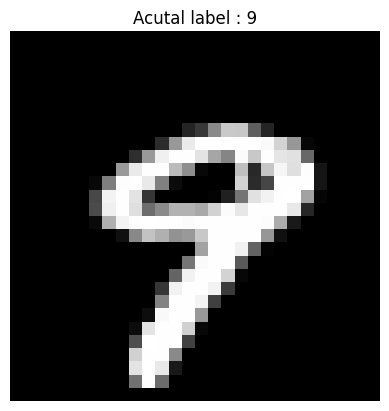

Prediction 9


In [10]:
#4/10/2026 ( model creation by myself )
import torch 
import torch.nn as nn
import torch.cuda
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available()  else "cpu"
print("Using device:",device)

transform = transforms.ToTensor()

train_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
    )

test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
    )

train_loader = DataLoader(train_data,
                        batch_size=70,
                        shuffle=True)

test_loader = DataLoader(train_data,
                        batch_size=70,
                        shuffle=True)

class proplayer(nn.Module):
    def __init__(self, ):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(28 * 28 , 512),
            nn.ReLU(),
            
            nn.Linear(512,256),
            nn.ReLU(),
            
            nn.Linear(256,128),
            nn.ReLU(),
            
            nn.Linear(128,64),
            nn.ReLU(),
            
            nn.Linear(64,10)
        )
        
    def forward(self,x):
        return self.net(x)

model = proplayer()

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

epochs = 5
total_loss = 0

for epoch in range(epochs):
    for images, labels in train_loader:
        model.train()
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs,labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    print(f"epoch:{epoch + 1} / epochs:{epochs}")
        
model.eval()
correct = 0
total = 0

with torch.no_grad():
     for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        
        correct += (labels == predictions).sum().item()
        total += labels.size(0)
        
accuracy = 100 * (correct/total)
print("Accuracy:",accuracy)

index = 9

image, true_label = test_data[index]
plt.imshow(image.squeeze(),cmap="gray")
plt.title(f"Acutal label : {true_label}")
plt.axis("off")
plt.show()

image_flat = image.view(1, -1).to(device)

with torch.no_grad():
    outputs = model(image_flat)
    prediction = outputs.argmax(dim=1).item()
    
print("Prediction",prediction)

Using device: cpu
epoch:1 / epochs:5 | Loss : 0.02426469326019287
epoch:2 / epochs:5 | Loss : 0.1070459634065628
epoch:3 / epochs:5 | Loss : 0.07201167941093445
epoch:4 / epochs:5 | Loss : 0.00550887593999505
epoch:5 / epochs:5 | Loss : 0.0001183537533506751
Accuracy: 98.78


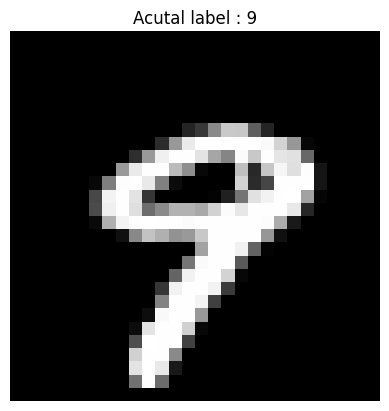

Prediction 9


In [4]:
#4/10/2026 ( model creation by myself ) ( now with conuvational)
import torch 
import torch.nn as nn
import torch.cuda
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available()  else "cpu"
print("Using device:",device)

transform = transforms.ToTensor()

train_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
    )

test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
    )

train_loader = DataLoader(train_data,
                        batch_size=70,
                        shuffle=True)

test_loader = DataLoader(test_data,
                        batch_size=70,
                        shuffle=True)

class simplecnn(nn.Module):
    def __init__(self, ):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1,8, kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(8,16, kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(16 * 7 * 7, 512),
            nn.ReLU(),
            
            nn.Linear(512,256),
            nn.ReLU(),
            
            nn.Linear(256,128),
            nn.ReLU(),
            
            nn.Linear(128,64),
            nn.ReLU(),
            
            nn.Linear(64,10)
        )
        
    def forward(self,x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = simplecnn().to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

epochs = 5

for epoch in range(epochs):
    
    total_loss = 0
    model.train()
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs,labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    print(f"epoch:{epoch + 1} / epochs:{epochs} | Loss : {loss}")
        
model.eval()
correct = 0
total = 0

with torch.no_grad():
     for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        
        correct += (labels == predictions).sum().item()
        total += labels.size(0)
        
accuracy = 100 * (correct/total)
print("Accuracy:",accuracy)

index = 9

image, true_label = test_data[index]
plt.imshow(image.squeeze(),cmap="gray")
plt.title(f"Acutal label : {true_label}")
plt.axis("off")
plt.show()

image_tensor = image.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(image_tensor)
    prediction = outputs.argmax(dim=1).item()
    
print("Prediction",prediction)